In [1]:
!pip install -q segmentation-models-pytorch albumentations kagglehub

In [2]:
from pathlib import Path
import os
import platform

import cv2
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import albumentations as A
import segmentation_models_pytorch as smp
from scipy import ndimage
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASSES = ["Fish", "Flower", "Gravel", "Sugar"]
NUM_CLASSES = len(CLASSES)
USE_AMP = torch.cuda.is_available()

torch.manual_seed(42)
torch.backends.cudnn.benchmark = True  # Ускорение сверток на GPU
cv2.setNumThreads(0)  # не даём OpenCV самому плодить потоки — они конкурируют с воркерами DataLoader
#IS_WINDOWS = platform.system() == "Windows"
NUM_CPU = os.cpu_count() or 4
np.random.seed(42)
print(f"Используемое устройство: {DEVICE}, mixed precision: {USE_AMP}")
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")
print(f"OS: {platform.system()}, логических ядер CPU: {NUM_CPU}")


C:\Users\User\PycharmProjects\otus-machine-learning-professional\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Используемое устройство: cuda, mixed precision: True
NVIDIA GeForce RTX 4080 SUPER
OS: Windows, логических ядер CPU: 16


In [3]:
# Загрузка данных
#данные скачаны локально
LOCAL_DATA_DIR = Path("data")

def resolve_data_path() -> Path:
    if (LOCAL_DATA_DIR / "train.csv").exists() and (LOCAL_DATA_DIR / "train_images").exists():
        return LOCAL_DATA_DIR.resolve()
    path = Path(kagglehub.competition_download("understanding_cloud_organization"))
    return path

DATA_PATH = resolve_data_path()
print("Path to dataset files:", DATA_PATH)

train_df = pd.read_csv(DATA_PATH / "train.csv")
print(f"Размер train.csv: {train_df.shape}")
train_df.head()

mask_dict = {
    row["Image_Label"]: row["EncodedPixels"]
    for _, row in train_df.iterrows()
}


Path to dataset files: C:\Users\User\PycharmProjects\otus-machine-learning-professional\homework_06\data
Размер train.csv: (22184, 2)


In [4]:
mask_dict = {
    row["Image_Label"]: row["EncodedPixels"]
    for _, row in train_df.iterrows()
}

In [5]:
#RLE-маски, EDA и стратифицированное разбиение train/val
def rle_decode(mask_rle: str, shape: tuple) -> np.ndarray:
    if pd.isna(mask_rle) or str(mask_rle).strip() == "":
        return np.zeros(shape, dtype=np.uint8)

    s = mask_rle.split()
    starts = np.array(s[0::2], dtype=int) - 1
    lengths = np.array(s[1::2], dtype=int)

    pixels = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for start, length in zip(starts, lengths):
        pixels[start:start+length] = 1
    return pixels.reshape(shape, order='F')

def build_masks(image_id: str, mask_dict: dict, shape: tuple) -> tuple:
    masks = np.zeros((NUM_CLASSES, shape[0], shape[1]), dtype=np.uint8)
    labels_present = np.zeros(NUM_CLASSES, dtype=np.float32)

    for class_idx, class_name in enumerate(CLASSES):
        key = f"{image_id}_{class_name}"
        rle = mask_dict.get(key, "")
        if rle and not pd.isna(rle) and str(rle).strip():
            m = rle_decode(rle, shape)
            masks[class_idx] = m
            if m.sum() > 0:
                labels_present[class_idx] = 1.0
    return masks, labels_present

Всего изображений: 5546


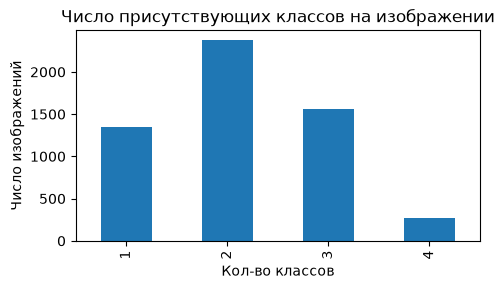

In [6]:
# EDA: сколько классов присутствует на каждом изображении — используем это для
# стратифицированного разбиения, чтобы train и val имели похожее распределение

image_ids = sorted({label.rsplit("_", 1)[0] for label in train_df["Image_Label"]})
print(f"Всего изображений: {len(image_ids)}")

has_mask = train_df["EncodedPixels"].notna() & (train_df["EncodedPixels"].astype(str).str.strip() != "")
label_count_df = (
    train_df.assign(has_mask=has_mask)
    .assign(image_id=train_df["Image_Label"].str.rsplit("_", n=1).str[0])
    .groupby("image_id")["has_mask"].sum()
)
label_count_df = label_count_df.reindex(image_ids)

plt.figure(figsize=(5, 3))
label_count_df.value_counts().sort_index().plot(kind="bar")
plt.title("Число присутствующих классов на изображении")
plt.xlabel("Кол-во классов")
plt.ylabel("Число изображений")
plt.tight_layout()
plt.show()


In [7]:
train_ids, val_ids = train_test_split(
        image_ids,
        test_size=0.2,
        random_state=42,
        stratify=label_count_df.values,
    )

print(f"Train: {len(train_ids)}, Val: {len(val_ids)}")

Train: 4436, Val: 1110


In [8]:
# Аугментации и Dataset
IMG_HEIGHT, IMG_WIDTH = 384, 576  # сохраняет соотношение сторон исходных кадров (~2:3)
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)
MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)

train_transform = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.5,
                       border_mode=cv2.BORDER_REFLECT),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.CoarseDropout(num_holes_range=(1, 4), hole_height_range=(8, 32),
                    hole_width_range=(8, 32), p=0.3),
    A.Normalize(mean=MEAN, std=STD),
])

val_transform = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH),
    A.Normalize(mean=MEAN, std=STD),
])

C:\Users\User\PycharmProjects\otus-machine-learning-professional\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [9]:
class CloudDataset(Dataset):
    def __init__(self, image_ids, mask_dict, images_dir, transform):
        self.image_ids = image_ids
        self.mask_dict = mask_dict
        self.images_dir = images_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image = cv2.imread(str(self.images_dir / image_id))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        orig_shape = (image.shape[0], image.shape[1])  # нужен ДО ресайза — для декодирования RLE

        # Маска берётся из дискового кэша уже уменьшенной до целевого размера —
        # см. get_masks_cached() ниже. Это убирает самую тяжёлую часть __getitem__:
        # RLE-декодирование в полном разрешении (1400x2100) в чистом Python-цикле,
        # которое иначе выполнялось бы заново на каждой эпохе для каждого изображения.
        masks_small, labels_present = get_masks_cached(image_id, self.mask_dict, orig_shape)
        masks_hwc = np.transpose(masks_small, (1, 2, 0))

        # Маска из кэша уже (IMG_HEIGHT, IMG_WIDTH) — albumentations проверяет, что размеры
        # image и mask совпадают ДО применения трансформаций, поэтому изображение тоже
        # приводим к целевому размеру здесь. A.Resize внутри transform от этого не ломается,
        # просто становится no-op (изображение уже нужного размера).
        image = cv2.resize(image, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_LINEAR)

        augmented = self.transform(image=image, mask=masks_hwc)

        image_t = torch.from_numpy(augmented["image"].transpose(2, 0, 1)).float()
        masks_t = torch.from_numpy(augmented["mask"].transpose(2, 0, 1)).float()
        labels_t = torch.from_numpy(labels_present).float()
        return image_t, masks_t, labels_t


# Кэш масок на диск
MASK_CACHE_DIR = Path("mask_cache")
MASK_CACHE_DIR.mkdir(exist_ok=True)


def get_masks_cached(image_id: str, mask_dict: dict, orig_shape: tuple) -> tuple:
    cache_path = MASK_CACHE_DIR / f"{image_id}.npz"
    if cache_path.exists():
        data = np.load(cache_path)
        return data["masks"], data["labels"]

    masks, labels_present = build_masks(image_id, mask_dict, orig_shape)
    masks_hwc = np.transpose(masks, (1, 2, 0))
    masks_small = cv2.resize(masks_hwc, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)
    if masks_small.ndim == 2:
        masks_small = masks_small[:, :, None]
    masks_small = np.transpose(masks_small, (2, 0, 1)).astype(np.uint8)
    try:
        np.savez_compressed(cache_path, masks=masks_small, labels=labels_present)
    except OSError:
        pass  # если диск недоступен для записи — просто работаем без кэша (без ускорения)
    return masks_small, labels_present


def worker_init_fn(worker_id):
    # каждый воркер по умолчанию пытается сам распараллелить OpenCV внутри себя —
    # это конкурирует за ядра CPU с самим DataLoader'ом
    cv2.setNumThreads(0)


BATCH_SIZE = 24

train_dataset = CloudDataset(train_ids, mask_dict, DATA_PATH / "train_images", train_transform)
val_dataset = CloudDataset(val_ids, mask_dict, DATA_PATH / "train_images", val_transform)

NUM_WORKERS = 0
PERSISTENT_WORKERS = NUM_WORKERS > 0

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
    persistent_workers=PERSISTENT_WORKERS,
    prefetch_factor=4 if NUM_WORKERS > 0 else None,
    worker_init_fn=worker_init_fn if NUM_WORKERS > 0 else None,
)
val_num_workers = max(0, NUM_WORKERS // 2)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=val_num_workers, pin_memory=torch.cuda.is_available(),
    persistent_workers=val_num_workers > 0,
    worker_init_fn=worker_init_fn if val_num_workers > 0 else None,
)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")
print(f"num_workers: train={NUM_WORKERS}, val={val_num_workers}")


Train batches: 185, Val batches: 47
num_workers: train=0, val=0


In [10]:
#Модель: Unet++ (EfficientNet-B0)
model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b3",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
    aux_params=dict(pooling="avg", dropout=0.3, activation=None, classes=NUM_CLASSES),
).to(DEVICE)

print("Модель: Unet++ с энкодером EfficientNet-B3 + классификационная голова")
print(f"Количество параметров: {sum(p.numel() for p in model.parameters()):,}")


Модель: Unet++ с энкодером EfficientNet-B3 + классификационная голова
Количество параметров: 13,626,768


In [11]:
# Функция потерь, метрика Dice, цикл обучения/валидации
def dice_coefficient(logits: torch.Tensor, targets: torch.Tensor, smooth: float = 1.0) -> torch.Tensor:
    '''Dice по бинаризованным (threshold=0.5) предсказаниям — используется для мониторинга.'''
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()
    dims = (0, 2, 3)
    intersection = (preds * targets).sum(dim=dims)
    union = preds.sum(dim=dims) + targets.sum(dim=dims)
    return ((2.0 * intersection + smooth) / (union + smooth)).mean()


def dice_per_class(logits: torch.Tensor, targets: torch.Tensor, smooth: float = 1.0) -> torch.Tensor:
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()
    intersection = (preds * targets).sum(dim=(0, 2, 3))
    union = preds.sum(dim=(0, 2, 3)) + targets.sum(dim=(0, 2, 3))
    return (2.0 * intersection + smooth) / (union + smooth)


class ComboLoss(nn.Module):
    '''BCE + Dice для сегментации, + BCE для вспомогательной классификационной головы.'''
    def __init__(self, smooth: float = 1.0, cls_weight: float = 0.3):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.cls_bce = nn.BCEWithLogitsLoss()
        self.smooth = smooth
        self.cls_weight = cls_weight

    def forward(self, seg_logits, seg_targets, cls_logits, cls_targets):
        bce_loss = self.bce(seg_logits, seg_targets)

        probs = torch.sigmoid(seg_logits)
        dims = (0, 2, 3)
        intersection = (probs * seg_targets).sum(dim=dims)
        union = probs.sum(dim=dims) + seg_targets.sum(dim=dims)
        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)
        dice_loss = 1.0 - dice.mean()

        cls_loss = self.cls_bce(cls_logits, cls_targets)
        return bce_loss + dice_loss + self.cls_weight * cls_loss


criterion = ComboLoss(cls_weight=0.3)

In [12]:
def run_epoch(model, loader, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss, total_dice, n_samples = 0.0, 0.0, 0

    for images, masks, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(is_train):
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                seg_logits, cls_logits = model(images)
                loss = criterion(seg_logits, masks, cls_logits, labels)

            if is_train:
                optimizer.zero_grad()
                if scaler is not None and USE_AMP:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # защита от взрыва градиента
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()  # backpropagation
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()  # шаг градиентного спуска (AdamW)

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        total_dice += dice_coefficient(seg_logits, masks).item() * batch_size
        n_samples += batch_size

    return total_loss / n_samples, total_dice / n_samples


In [13]:
# Обучение: AdamW + OneCycleLR + AMP + ранняя остановка по val Dice
import time

EPOCHS = 40
LEARNING_RATE = 3e-4
PATIENCE = 8

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    pct_start=0.1,
)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

history = {"train_loss": [], "val_loss": [], "train_dice": [], "val_dice": []}
best_val_dice = -1.0
best_state = None
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    epoch_start_time = time.time()  # засекаем время начала эпохи

    model.train(True)
    total_loss, total_dice, n_samples = 0.0, 0.0, 0
    for images, masks, labels in train_loader:
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            seg_logits, cls_logits = model(images)
            loss = criterion(seg_logits, masks, cls_logits, labels)

        optimizer.zero_grad()
        if USE_AMP:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        scheduler.step()

        bs = images.size(0)
        total_loss += loss.item() * bs
        total_dice += dice_coefficient(seg_logits, masks).item() * bs
        n_samples += bs

    train_loss, train_dice = total_loss / n_samples, total_dice / n_samples
    val_loss, val_dice = run_epoch(model, val_loader)

    epoch_elapsed = time.time() - epoch_start_time  # время выполнения эпохи

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)

    print(
        f"\nEpoch {epoch:02d}/{EPOCHS} | "
        f"train loss={train_loss:.4f}, dice={train_dice:.4f} | "
        f"val loss={val_loss:.4f}, dice={val_dice:.4f} | "
        f"lr={optimizer.param_groups[0]['lr']:.2e} | "
        f"time={epoch_elapsed:.1f}s"
    )

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, "best_model.pth")
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping: val Dice не улучшался {PATIENCE} эпох подряд.")
            break

if best_state is not None:
    model.load_state_dict(best_state)

print(f"\nЛучший val Dice (порог 0.5, без TTA): {best_val_dice:.4f}")

C:\Users\User\AppData\Local\Temp\ipykernel_9096\3065326695.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
C:\Users\User\AppData\Local\Temp\ipykernel_9096\3065326695.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
C:\Users\User\AppData\Local\Temp\ipykernel_9096\2241802452.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 01/40 | train loss=1.7075, dice=0.2774 | val loss=1.7254, dice=0.3383 | lr=5.43e-05 | time=242.2s
Epoch 02/40 | train loss=1.3778, dice=0.3801 | val loss=1.2054, dice=0.4334 | lr=1.56e-04 | time=301.6s
Epoch 03/40 | train loss=1.1011, dice=0.4869 | val loss=1.0289, dice=0.5713 | lr=2.58e-04 | time=367.2s
Epoch 04/40 | train loss=0.9890, dice=0.5656 | val loss=0.9742, dice=0.5802 | lr=3.00e-04 | time=350.5s
Epoch 05/40 | train loss=0.9376, dice=0.5878 | val loss=0.9584, dice=0.5806 | lr=2.99e-04 | time=416.6s
Epoch 06/40 | train loss=0.9092, dice=0.5984 | val loss=0.9631, dice=0.5756 | lr=2.98e-04 | time=444.1s
Epoch 07/40 | train loss=0.8692, dice=0.6160 | val loss=0.9255, dice=0.5833 | lr=2.95e-04 | time=268.0s
Epoch 08/40 | train loss=0.8496, dice=0.6243 | val loss=0.9396, dice=0.5861 | lr=2.91e-04 | time=289.9s
Epoch 09/40 | train loss=0.8238, dice=0.6340 | val loss=0.9582, dice=0.5761 | lr=2.86e-04 | time=396.2s
Epoch 10/40 | train loss=0.7919, dice=0.6500 | val loss=0.9912, 

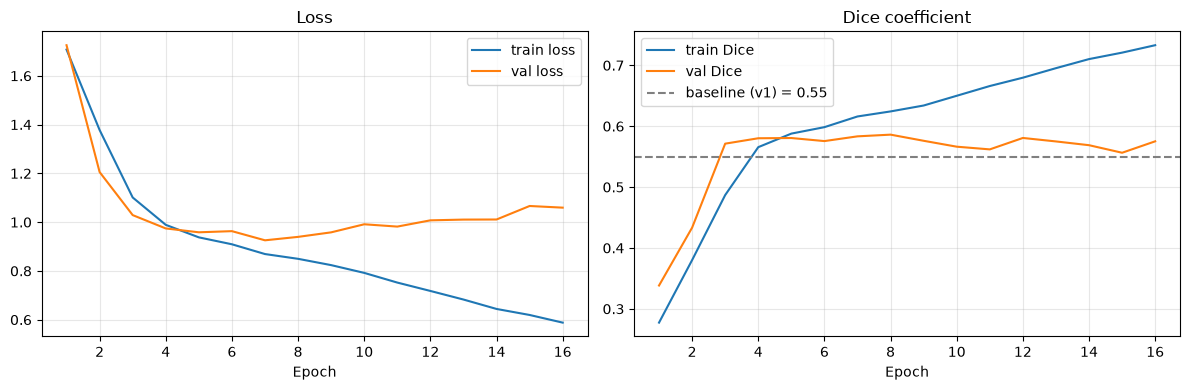

In [14]:
# График обучения
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="train loss")
axes[0].plot(epochs_range, history["val_loss"], label="val loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history["train_dice"], label="train Dice")
axes[1].plot(epochs_range, history["val_dice"], label="val Dice")
axes[1].axhline(0.55, color="gray", linestyle="--", label="baseline (v1) = 0.55")
axes[1].set_title("Dice coefficient")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [15]:
# Постобработка: TTA + подбор порога и минимального размера маски по классам
def remove_small_components(mask: np.ndarray, min_size: int) -> np.ndarray:
    labeled, n = ndimage.label(mask)
    if n == 0:
        return mask
    sizes = ndimage.sum(mask, labeled, range(1, n + 1))
    out = np.zeros_like(mask)
    for i, s in enumerate(sizes, start=1):
        if s >= min_size:
            out[labeled == i] = 1
    return out


def dice_np(pred: np.ndarray, target: np.ndarray, smooth: float = 1.0) -> float:
    inter = (pred * target).sum()
    return (2 * inter + smooth) / (pred.sum() + target.sum() + smooth)


@torch.no_grad()
def predict_with_tta(model, images):
    '''Усреднение предсказаний исходного изображения и его horizontal-flip копии.'''
    seg_logits, _ = model(images)
    probs = torch.sigmoid(seg_logits)

    seg_logits_flip, _ = model(torch.flip(images, dims=[3]))
    probs_flip = torch.sigmoid(torch.flip(seg_logits_flip, dims=[3]))

    return ((probs + probs_flip) / 2.0).cpu().numpy()


In [16]:
model.eval()
all_probs, all_targets = [], []
for images, masks, _ in val_loader:
    images = images.to(DEVICE)
    probs = predict_with_tta(model, images)
    all_probs.append(probs)
    all_targets.append(masks.numpy())

all_probs = np.concatenate(all_probs, axis=0)     # [N, C, H, W]
all_targets = np.concatenate(all_targets, axis=0)  # [N, C, H, W]
print("Собрано предсказаний на валидации:", all_probs.shape)


Собрано предсказаний на валидации: (1110, 4, 384, 576)


In [17]:
THRESHOLDS_TO_TRY = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]
MIN_SIZES_TO_TRY = [0, 5000, 10000, 15000, 20000]

best_thresholds = {}
best_min_sizes = {}
per_class_dice = {}

for c, class_name in enumerate(CLASSES):
    best_score, best_t, best_ms = -1.0, 0.5, 0
    for t in THRESHOLDS_TO_TRY:
        preds_bin = (all_probs[:, c] > t).astype(np.uint8)
        for ms in MIN_SIZES_TO_TRY:
            if ms > 0:
                preds_clean = np.stack([remove_small_components(p, ms) for p in preds_bin])
            else:
                preds_clean = preds_bin
            score = dice_np(preds_clean, all_targets[:, c])
            if score > best_score:
                best_score, best_t, best_ms = score, t, ms
    best_thresholds[class_name] = best_t
    best_min_sizes[class_name] = best_ms
    per_class_dice[class_name] = best_score
    print(f"{class_name:8s}: threshold={best_t:.2f}, min_size={best_ms:6d}, Dice={best_score:.4f}")

final_val_dice = float(np.mean(list(per_class_dice.values())))
print(f"\nИтоговый val Dice после TTA + подбора порога/min_size: {final_val_dice:.4f}")
print(f"Baseline (v1): 0.5500  |  Улучшение: {final_val_dice - 0.55:+.4f}")


Fish    : threshold=0.55, min_size= 10000, Dice=0.5472
Flower  : threshold=0.55, min_size=  5000, Dice=0.6968
Gravel  : threshold=0.50, min_size= 10000, Dice=0.5806
Sugar   : threshold=0.30, min_size=     0, Dice=0.6026

Итоговый val Dice после TTA + подбора порога/min_size: 0.6068
Baseline (v1): 0.5500  |  Улучшение: +0.0568


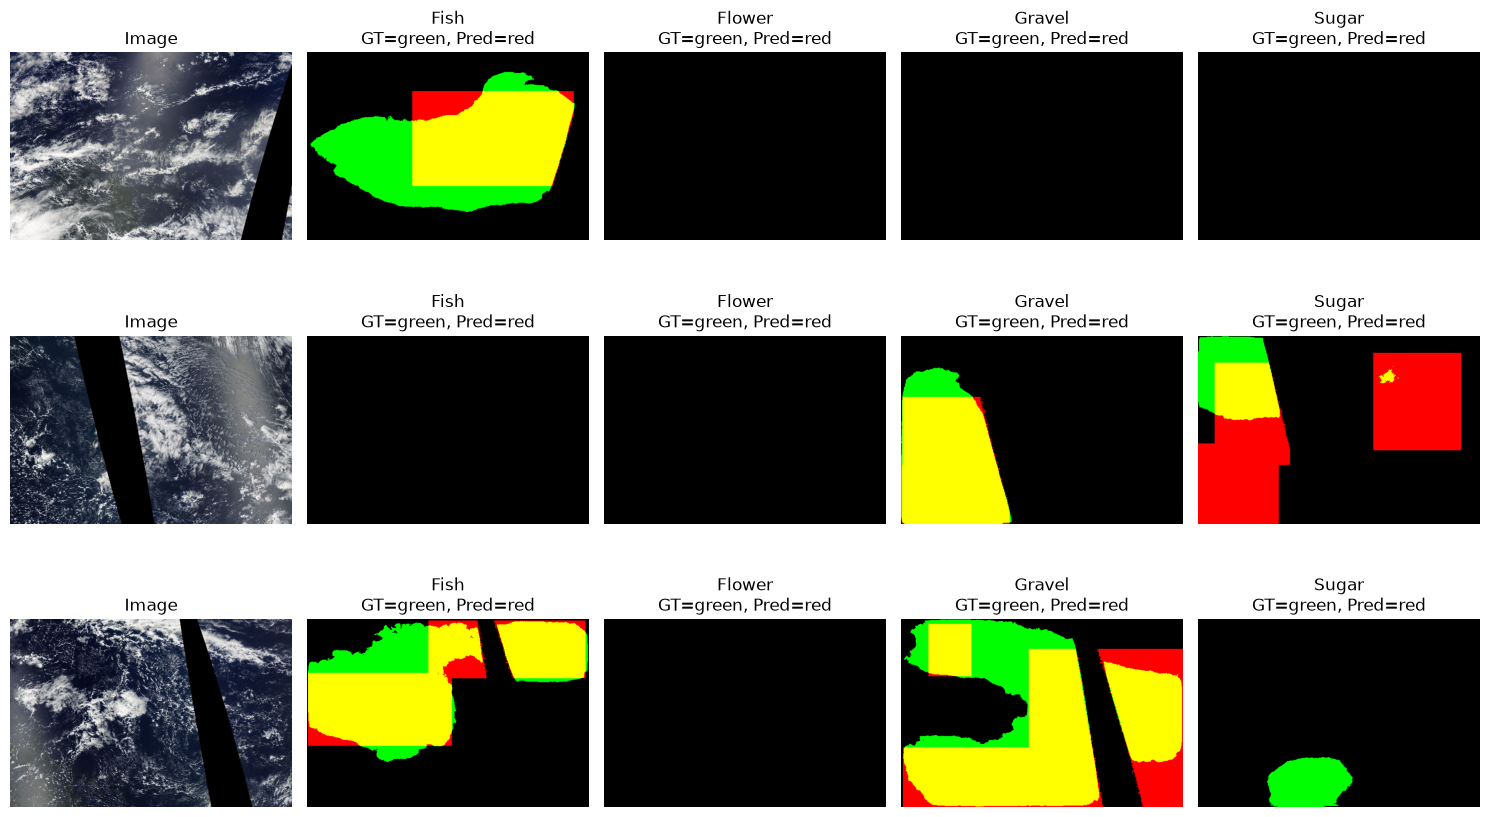

In [18]:
# Визуализация предсказаний (с подобранными порогами)
model.eval()
images, masks, _ = next(iter(val_loader))
images_gpu = images.to(DEVICE)
probs = predict_with_tta(model, images_gpu)

preds = np.zeros_like(probs)
for c, class_name in enumerate(CLASSES):
    t = best_thresholds[class_name]
    ms = best_min_sizes[class_name]
    preds_bin = (probs[:, c] > t).astype(np.uint8)
    if ms > 0:
        preds_bin = np.stack([remove_small_components(p, ms) for p in preds_bin])
    preds[:, c] = preds_bin

mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)

n_show = min(3, images.size(0))
fig, axes = plt.subplots(n_show, NUM_CLASSES + 1, figsize=(3 * (NUM_CLASSES + 1), 3 * n_show))
if n_show == 1:
    axes = np.expand_dims(axes, axis=0)

images_np = images.numpy()
masks_np = masks.numpy()

for row in range(n_show):
    img = images_np[row] * std + mean
    img = np.transpose(img, (1, 2, 0)).clip(0, 1)
    axes[row, 0].imshow(img)
    axes[row, 0].set_title("Image")
    axes[row, 0].axis("off")

    for col, class_name in enumerate(CLASSES, start=1):
        gt = masks_np[row, col - 1]
        pr = preds[row, col - 1]
        overlay = np.stack([gt, pr, np.zeros_like(gt)], axis=-1)
        axes[row, col].imshow(overlay)
        axes[row, col].set_title(f"{class_name}\nGT=green, Pred=red")
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()


In [19]:
# Итоговая оценка и сравнение с первой версией
print("Dice coefficient по классам (val, TTA + подобранные пороги):")
for class_name in CLASSES:
    print(f"  {class_name}: {per_class_dice[class_name]:.4f}  "
          f"(threshold={best_thresholds[class_name]:.2f}, min_size={best_min_sizes[class_name]})")

print(f"\nСредний Dice (macro), TTA + постобработка: {final_val_dice:.4f}")
print(f"Средний Dice (без TTA/постобработки, порог 0.5): {best_val_dice:.4f}")
print(f"Baseline (версия 1, U-Net ResNet34):            0.5500")


Dice coefficient по классам (val, TTA + подобранные пороги):
  Fish: 0.5472  (threshold=0.55, min_size=10000)
  Flower: 0.6968  (threshold=0.55, min_size=5000)
  Gravel: 0.5806  (threshold=0.50, min_size=10000)
  Sugar: 0.6026  (threshold=0.30, min_size=0)

Средний Dice (macro), TTA + постобработка: 0.6068
Средний Dice (без TTA/постобработки, порог 0.5): 0.5861
Baseline (версия 1, U-Net ResNet34):            0.5500
